# Contrastive Divergence Algorithm

In [32]:
# Check for all needed packages
import numpy
import matplotlib
import mnists
# In case of ImportError, install them to the running kernel with
# %pip install numpy matplotlib mnists
# or the the runtime container with:
# !pip install numpy matplotlib mnists
# (In case of the latter, remember to restart the kernel!)

In [33]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(1234)

try:
    import mkl
    mkl.set_num_threads(2)
except ImportError:
    print("Intel Math Kernel Library (MKL) does not always work on every machine. "
          "Continuing without `mkl`.")

%matplotlib inline
%config InlineBackend.figure_format = 'retina'
plt.rcParams["figure.figsize"] = [16, 9]

Intel Math Kernel Library (MKL) does not always work on every machine. Continuing without `mkl`.


### Handy utility functions

In [34]:
def append_ones(matrix: np.ndarray) -> np.ndarray:
    """
    Appends a column of ones to the right side of a 2D matrix.
    """
    return np.concatenate((matrix, np.ones((matrix.shape[0], 1), dtype=np.float32)), axis=1)


def zeros(*dims: int) -> np.ndarray:
    """
    Creates a NumPy array of zeros with the given shape.

    Args:
        *dims:  Variable number of integers defining the shape of the array.
                E.g. zeros(3, 4) creates a (3, 4) array.
    """
    return np.zeros(shape=tuple(dims), dtype=np.float32)
def ones(*dims: int) -> np.ndarray:
    """
    Creates a NumPy array of ones with the given shape.

    Args:
        *dims:  Variable number of integers defining the shape of the array.
                E.g. ones(3, 4) creates a (3, 4) array.
    """
    return np.ones(shape=tuple(dims), dtype=np.float32)

def rand(*dims: int) -> np.ndarray:
    """
    Creates a NumPy array of random values sampled from a uniform [0, 1) distribution.

    Args:
        *dims:  Variable number of integers defining the shape of the array.
                E.g. rand(3, 4) creates a (3, 4) array.
    """
    return np.random.rand(*dims).astype(np.float32)

def chunks(seq: list, size: int) -> tuple[np.ndarray]:
    """
    Splits a sequence into consecutive chunks of a given size.

    The last chunk may be smaller than `size` if the sequence length
    is not evenly divisible.

    Args:
        seq:  The input sequence (e.g. list or other sliceable) to split.
        size: The maximum number of elements in each chunk.

    Returns:
        Successive sub-sequences of length `size` (or less for the final chunk).
    """
    return tuple([seq[pos:(pos + size)] for pos in range(0, len(seq), size)])

def arrange_tiles_img(examples: np.ndarray) -> np.ndarray:
    """
    Arrange 2D matrices as tiles

    Takes 4D `examples` tensor with dims:
        rows x cols x tile_height x tile_width
    """
    rows_count = examples.shape[0]
    cols_count = examples.shape[1]
    tile_height = examples.shape[2]
    tile_width = examples.shape[3]

    space_between_tiles = 2
    img_matrix = np.empty(shape=(rows_count * (tile_height + space_between_tiles) - space_between_tiles,
                                 cols_count * (tile_width + space_between_tiles) - space_between_tiles))
    img_matrix.fill(np.nan)

    for r in range(rows_count):
        for c in range(cols_count):
            x_0 = r * (tile_height + space_between_tiles)
            y_0 = c * (tile_width + space_between_tiles)
            img_matrix[x_0:x_0 + tile_height, y_0:y_0 + tile_width] = examples[r, c]

    return img_matrix

def preview_tiles(examples: np.ndarray) -> np.ndarray:
    """Previews the arrange tiles"""
    img = arrange_tiles_img(examples)
    plt.matshow(img, cmap='gray', interpolation='none')
    plt.axis('off')
    plt.show()

# MNIST dataset

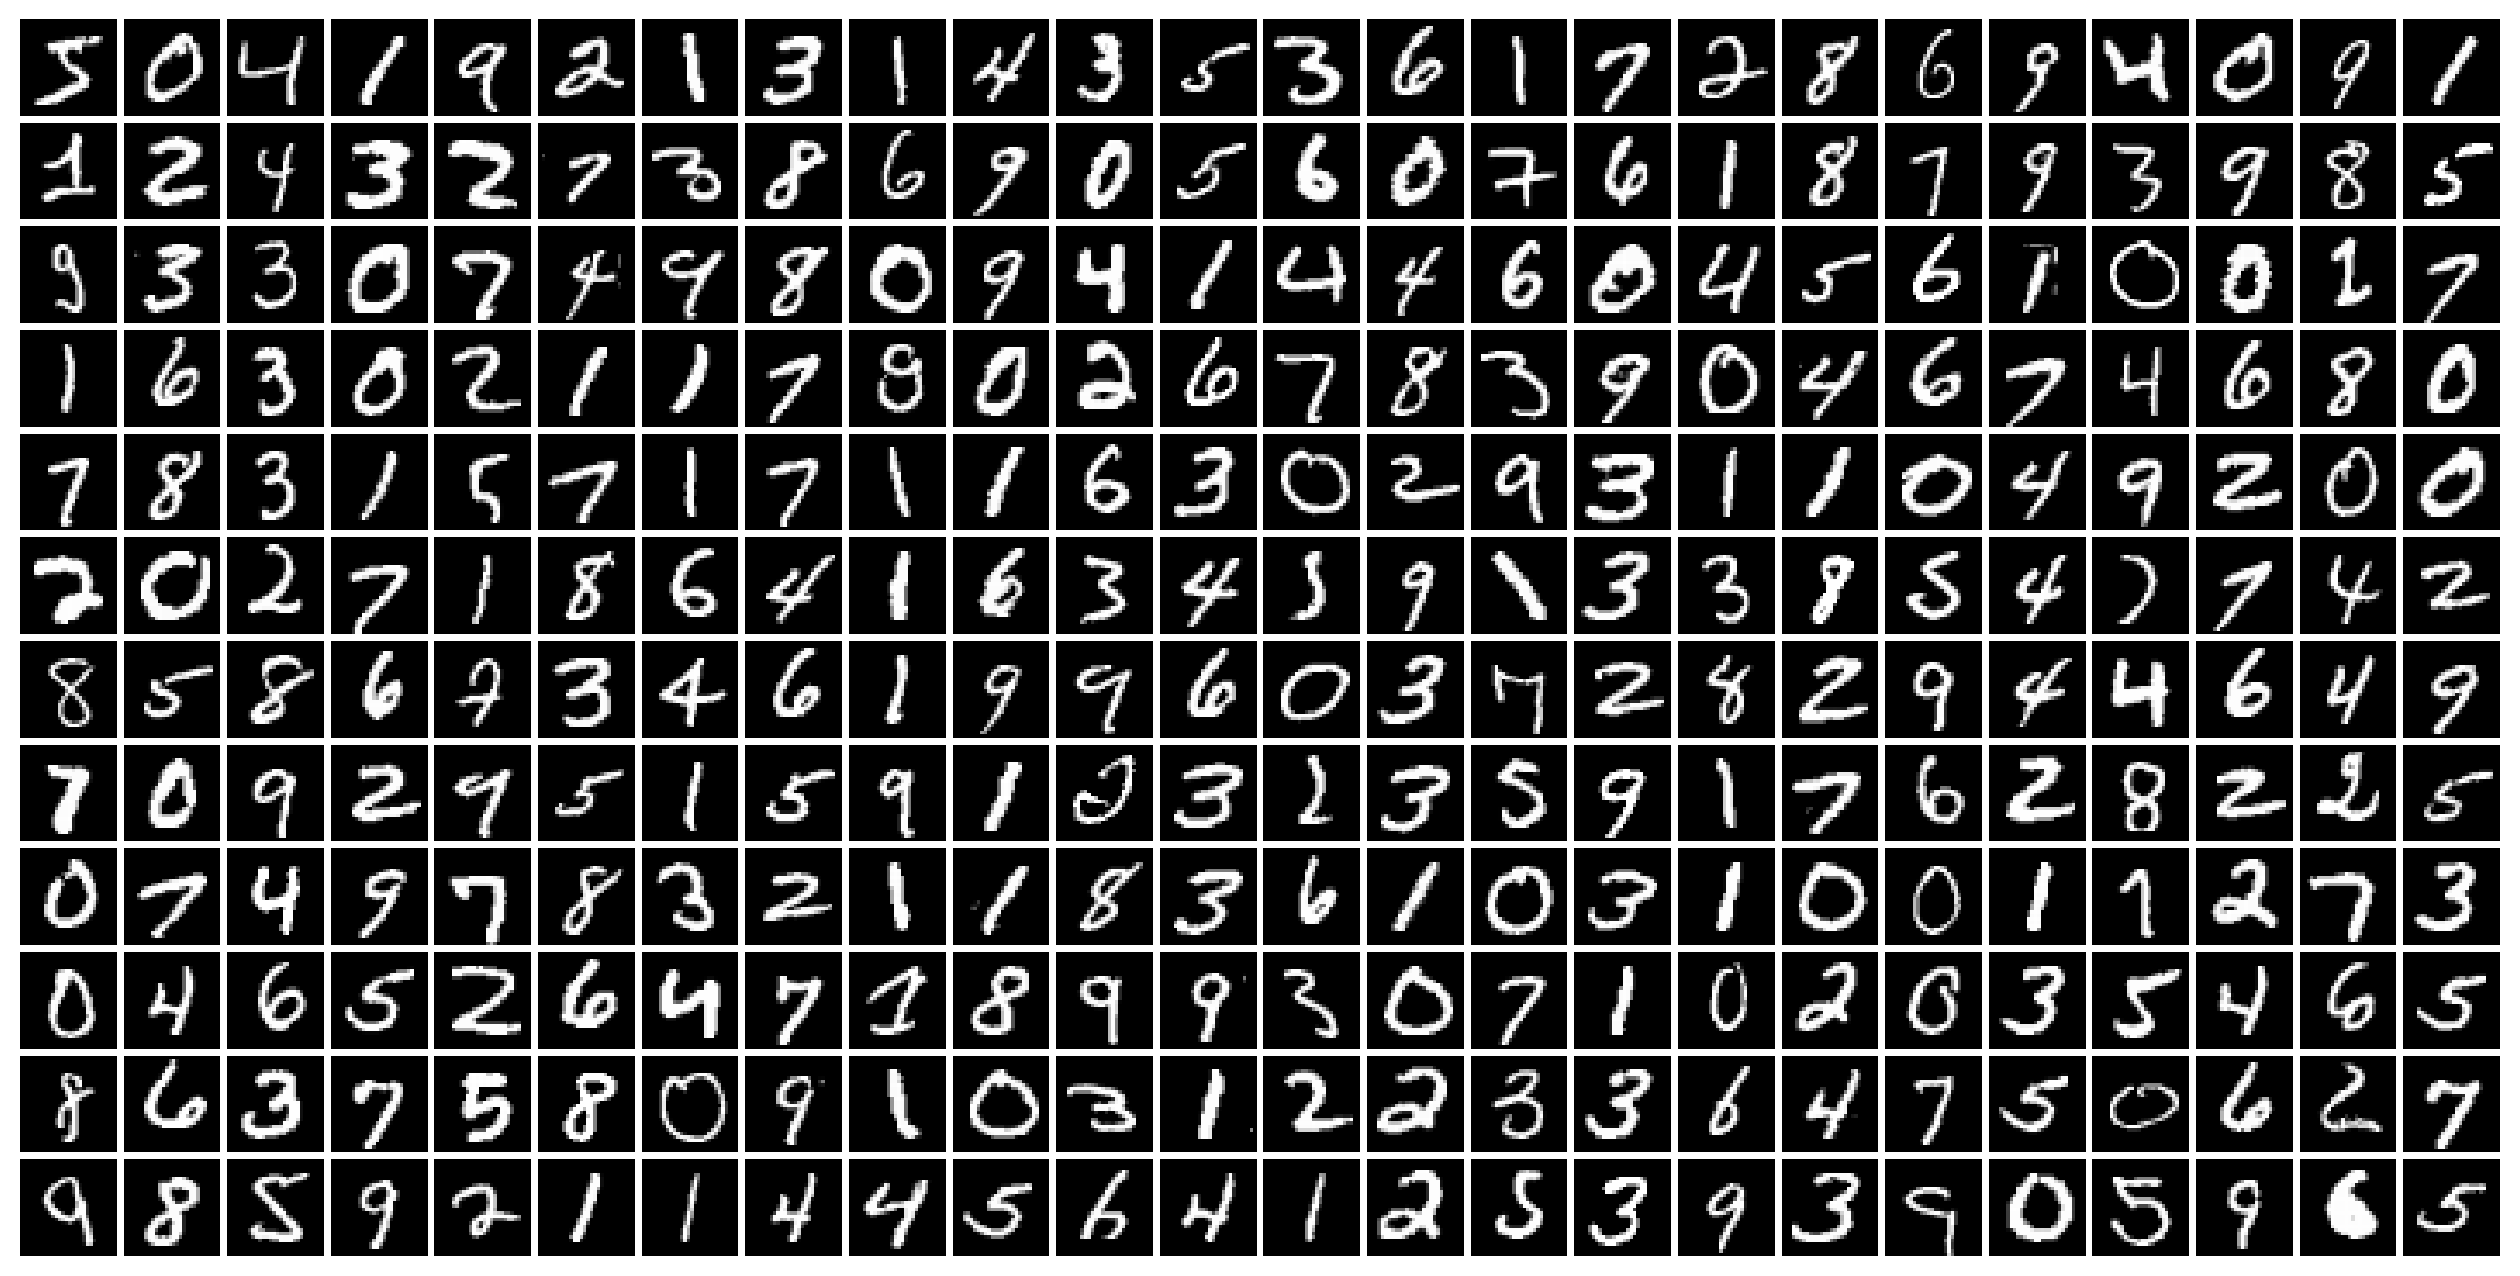

In [35]:
from mnists import MNIST
mnist = MNIST()

def create_mnist_digits() -> np.ndarray:
    n_rows = 12
    n_cols = 24
    tile_dim = 28 # [px]
    shape = (n_rows, n_cols, tile_dim, tile_dim)
    return np.reshape(mnist.train_images()[:12*24], shape)

mnist_digits = create_mnist_digits()

preview_tiles(mnist_digits)

# Restricted Boltzmann Machine & Contrastive Divergence algorithm

In [36]:
def sigmoid(x: np.ndarray) -> np.ndarray:
    """
    Applies the sigmoid (logistic) activation function element-wise.

    Squashes each value in `x` to the range (0, 1), which is
    interpreted as an activation probability in the RBM context.
    """
    return 1.0 / (1.0 + np.exp(-x))

class RestrictedBoltzmanMachine:
    """
    A Restricted Boltzmann Machine (RBM) with a single visible and hidden layer.

    The weight matrix W has shape (visible_size + 1, hidden_size + 1), where
    the extra row and column are reserved for bias units.

    Attributes:
        visible_size:  Number of visible (input) units, excluding the bias.
        hidden_size:   Number of hidden units, excluding the bias.
        learning_rate: Step size used during contrastive divergence updates.
        W:             Weight matrix of shape (visible_size+1, hidden_size+1).
    """

    def __init__(
        self,
        visible_size: int,
        hidden_size: int,
        learning_rate: float
    ):
        self.visible_size = visible_size
        self.hidden_size = hidden_size
        self.learning_rate = learning_rate
        
        self.reset()
        
    def reset(self) -> None:
        self.W = np.random.normal(
            scale=0.01, 
            size=(self.visible_size + 1, self.hidden_size + 1),
        ).astype(np.float32)
        
        self.W[:, -1] = 0.0   # zero hidden-bias weights
        self.W[-1, :] = 0.0   # zero visible-bias weights

## Algorithm description

### [EN] Description of the Contrastive Divergence (CD-k) algorithm

$\renewcommand{\vect}[1]{\mathbf{#1}}$
In an RBM network, the gradient of the cost function with respect to the weights is given by:

$\frac{\delta}{\delta w_{ij}} -\log P(\vect{v}) = -\mathbf{E}[v_i h_j \vert \vect{v}] + \mathbf{E}[v_i h_j]$

#### Positive phase — corresponds to the $\mathbf{E}[v_i h_j \vert \vect{v}]$ term

This part of the gradient is computed by calculating the products $v_i h_j$ between the elements of the observation vector ($v_i$) and the activation probabilities in the hidden layer ($h_j$). This operation can be written in vectorised form as:

$\nabla_P = \vect{v}^T\sigma(\vect{vW})$

#### Negative phase — corresponds to the $\mathbf{E}[v_i h_j]$ term

We start from the hidden-layer activation probabilities computed during the positive phase and use them to draw a sample of hidden-layer activations:

$\vect{h} = \sigma (\vect{vW}) > [rand_1, rand_2, \dots, rand_m]$

We then draw a sample of visible-layer activations:

$\vect{v}_1 = \sigma (\vect{hW}^T) > [rand_1, rand_2, \dots, rand_n]$

To obtain the RBM *fantasy*, the above samples are drawn (alternately) $k$ times, where $k$ is the parameter of the CD-*k* algorithm:

$\vect{h}_{k-1} = \sigma (\vect{v}_{k-1}\vect{W}) > [rand_1, rand_2, \dots, rand_m]$,  
$\vect{v}_k = \sigma (\vect{h}_{k-1}\vect{W}^T) > [rand_1, rand_2, \dots, rand_n]$

The negative part of the gradient is computed by calculating the products $v_{k_i} h_j$ between the elements of the RBM *fantasy* vector ($v_{k_i}$) and the hidden-layer activation probabilities computed for that *fantasy* ($h_j$). This operation can be written in vectorised form as:

$\nabla_N = \vect{v}_k^T\sigma(\vect{v}_k\vect{W})$

#### RBM weight matrix update

Training is performed via stochastic gradient descent:

$\phi_{t+1} \leftarrow \phi_t - \epsilon \nabla$

which for the RBM gradient gives:

$W_{t+1} \leftarrow W_t + \epsilon \nabla_P - \epsilon \nabla_N$

### [PL] Opis algorytmu Contrastive Divergence (CD-k)

$\renewcommand{\vect}[1]{\mathbf{#1}}$
W sieci RBM gradient funkcji kosztu względem wag wyznaczamy zgodnie ze wzorem:

$\frac{\delta}{\delta w_{ij}} -\log P(\vect{v}) = -\mathbf{E}[v_i h_j \vert \vect{v}] + \mathbf{E}[v_i h_j]$

#### Faza pozytywna - odpowiada za część $\mathbf{E}[v_i h_j \vert \vect{v}]$

Tą część gradientu wyznaczamy przez wyliczenie iloczynów $v_i h_j$ pomiędzy elementami wektora obserwacji ($v_i$) a prawdopodobieństwami aktywacji w warstwie ukrytej ($h_j$). Operację tą możemy zapisać w postaci zwektoryzowanej jako:

$\nabla_P = \vect{v}^T\sigma(\vect{vW})$

#### Faza negatywna - odpowiada za część $\mathbf{E}[v_i h_j]$

Rozpoczynamy od prawdopodobieństw aktywacji neuronów w warstwie ukrytej, które zostały wyznaczone w fazie pozytywnej. Na ich podstawie losujemy próbkę aktywacji w warstwie ukrytej:

$\vect{h} = \sigma (\vect{vW}) > [rand_1, rand_2, \dots, rand_m]$

Następnie losujemy próbkę aktywacji w warstwie widocznej:

$\vect{v}_1 = \sigma (\vect{hW}^T) > [rand_1, rand_2, \dots, rand_n]$

Aby wyznaczyć *fantazję* sieci RBM, powyższe próbki losujemy (naprzemiennie) $k$ razy (gdzie $k$ to parametr algorytmu CD-*k*):

$\vect{h}_{k-1} = \sigma (\vect{v}_{k-1}\vect{W}) > [rand_1, rand_2, \dots, rand_m]$, 
$\vect{v}_k = \sigma (\vect{h}_{k-1}\vect{W}^T) > [rand_1, rand_2, \dots, rand_n]$

Część negatywną gradientu wyznaczamy poprzez wyliczenie iloczynów $v_{k_i} h_j$ pomiędzy elementami wektora *fantazji* RBM ($v_{k_i}$) a prawdopodobieństwami aktywacji w warstwie ukrytej wyliczonymi dla tejże *fantazji* ($h_j$). Operację tą możemy zapisać w postaci zwektoryzowanej jako:

$\nabla_N = \vect{v}_k^T\sigma(\vect{v}_k\vect{W})$


#### Aktualizacja macierzy wag RBM

Uczymy stochastycznym spadkiem wzdłuż gradientu:

$\phi_{t+1} \leftarrow \phi_t - \epsilon \nabla$

co dla gradientu RBM daje:

$W_{t+1} \leftarrow W_t + \epsilon \nabla_P - \epsilon \nabla_N$

## CK-d implementation

In [37]:
def contrastive_divergence_update(rbm: RestrictedBoltzmanMachine, minibatch: np.ndarray, k: int = 1) -> None:
    """
    Performs a single Contrastive Divergence (CD-k) weight update in-place.

    CD-k approximates the log-likelihood gradient by running k steps of
    Gibbs sampling starting from the training data.  The resulting
    positive and negative phase statistics are used to update weights rbm.W.

    All visible and hidden arrays carry an appended bias column (via
    `append_ones`), so matrix multiplications automatically include biases.

    Args:
        rbm:        The RBM whose weights will be updated.
        minibatch:  A 2D float32 array of shape (n, visible_size + 1),
                    where the last column is the bias (all ones).
        k:          Number of Gibbs sampling steps (default 1, i.e. CD-1).
    """
    observations_count = minibatch.shape[0]

    # ---- Positive phase: clamp visible units to data ----
    positive_visible = minibatch
    negative_visible = append_ones(zeros(observations_count, rbm.visible_size))

    # ---- Negative phase: initialise with a stochastic hidden sample ----
    positive_hidden = append_ones(zeros(observations_count, rbm.hidden_size))
    negative_hidden = append_ones(zeros(observations_count, rbm.hidden_size))

    #TODO Implement the Contrastive Divergence (CD-k) weight update algorithm

    positive_hidden_probs = sigmoid(positive_visible @ rbm.W)
    positive_hidden_probs[:, -1] = 1.0
    positive_hidden = (positive_hidden_probs > rand(*positive_hidden_probs.shape)).astype(np.float32)
    positive_hidden[:, -1] = 1.0

    negative_hidden = positive_hidden.copy()

    for _ in range(k):

        negative_visible_probs = sigmoid(negative_hidden @ rbm.W.T)
        negative_visible_probs[:, -1] = 1.0
        negative_visible = (negative_visible_probs > rand(*negative_visible_probs.shape)).astype(np.float32)
        negative_visible[:, -1] = 1.0


        negative_hidden_probs = sigmoid(negative_visible @ rbm.W)
        negative_hidden_probs[:, -1] = 1.0
        negative_hidden = (negative_hidden_probs > rand(*negative_hidden_probs.shape)).astype(np.float32)
        negative_hidden[:, -1] = 1.0

    positive_gradient = positive_visible.T @ positive_hidden_probs
    negative_gradient = negative_visible.T @ negative_hidden_probs

    rbm.W += rbm.learning_rate * (positive_gradient - negative_gradient) / observations_count
    

### RBM reconstruction error

In [38]:
def reconstruction_error(rbm: RestrictedBoltzmanMachine, minibatch: np.ndarray) -> float:
    """
    Computes the mean per-sample reconstruction error on a minibatch.

    Runs a single forward-backward pass (encode then decode) without
    weight updates and returns the average squared difference between
    the original visible units and their reconstructions.

    Args:
        rbm:        The trained (or partially trained) RBM.
        minibatch:  A 2D float32 array of shape (n, visible_size + 1),
                    with the bias column appended.

    Returns:
        A scalar float: sum of squared errors divided by the number
        of observations.
    """
    observations_count = minibatch.shape[0]
    visible = zeros(observations_count, rbm.visible_size)
    hidden = append_ones(zeros(observations_count, rbm.hidden_size))

    #TODO Implement the reconstuction error
    visible = minibatch[:, :-1]

    hidden_probs = sigmoid(minibatch @ rbm.W)
    hidden_probs[:, -1] = 1.0
    hidden = hidden_probs

    visible_probs = sigmoid(hidden @ rbm.W.T)
    visible = visible_probs[:, :-1]

    error = np.sum((minibatch[:, :-1] - visible) ** 2) / observations_count

    return error

# RBM Training

In [39]:
import time

DATASET_SIZE: int = 20000 # 60000 for whole dataset
DIGIT_SIZE: int = 28

VISIBLE_LAYER_SIZE: int = DIGIT_SIZE*DIGIT_SIZE
HIDDEN_LAYER_SIZE: int = 128
LEARNING_RATE: float = 0.1

mnist_train = mnist.train_images().astype(np.float32) / 255.0

np.random.shuffle(mnist_train)
dataset = np.reshape(mnist_train[:DATASET_SIZE], (DATASET_SIZE, DIGIT_SIZE*DIGIT_SIZE))
dataset = append_ones(dataset)

monitoring_indeces = np.random.choice(DATASET_SIZE, 256, replace=False)
monitoring_set = dataset[monitoring_indeces]

rbm_model = RestrictedBoltzmanMachine(VISIBLE_LAYER_SIZE, HIDDEN_LAYER_SIZE, LEARNING_RATE)

In [40]:
def draw_filters(rbm: RestrictedBoltzmanMachine) -> None:
    """
    Visualises the learned RBM weight filters as a grid of 28×28 tiles.

    Transposes W, strips the bias row/column, reshapes the hidden-unit
    weight vectors into 28×28 images, clips extreme values to [-1, 1],
    and renders them using `tiles`.

    Args:
        rbm: A trained RBM whose W has shape (visible_size+1, hidden_size+1).
    """
    filters: np.ndarray = np.reshape(
        np.transpose(rbm.W)[:-1, :-1],
        #newshape=(8, -1, 28, 28),
        (8, -1, 28, 28)
    )
    filters = np.clip(filters, -1, 1)
    preview_tiles(filters)

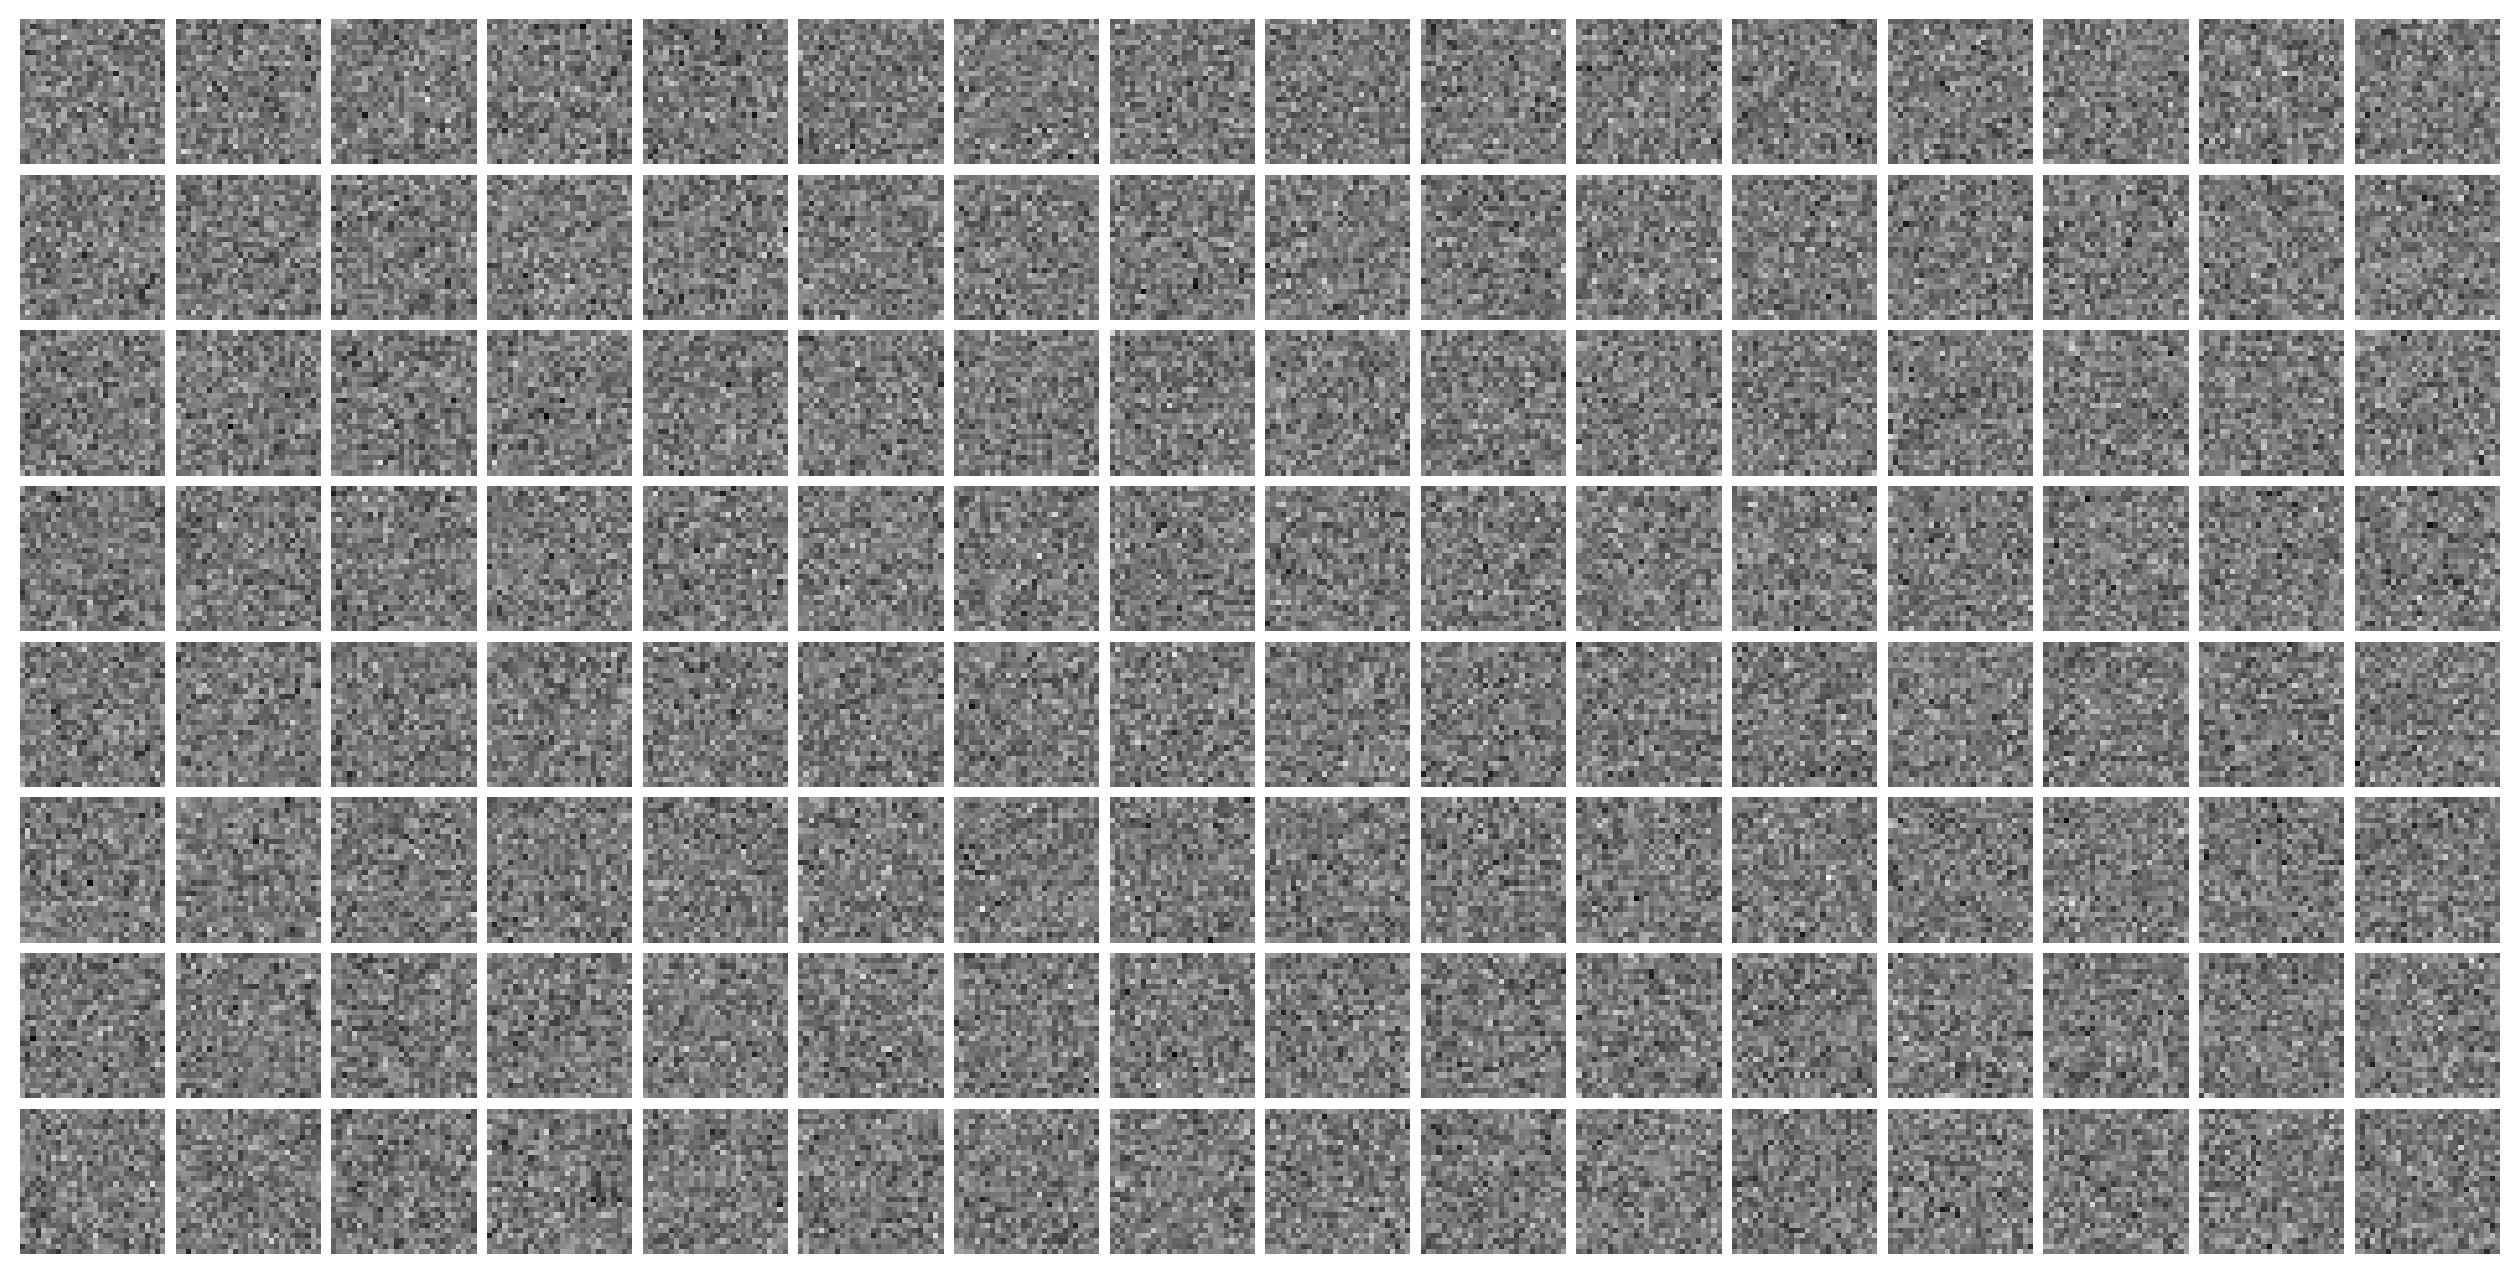

In [41]:
draw_filters(rbm_model)

In [42]:
BATCH_SIZE: int = 128
EPOCHS_COUNT: int = 50

def train_epoch(rbm: RestrictedBoltzmanMachine, dataset: np.ndarray) -> None:
    batches_limit = dataset.shape[0] / BATCH_SIZE
    for batch_idx, batch in enumerate(chunks(dataset, BATCH_SIZE)):
        contrastive_divergence_update(rbm, batch)
        if batch_idx % round(batches_limit / 50) == 0: print("#", end="")

rbm_model.reset()
for epoch in range(EPOCHS_COUNT):
    print(f"Epoch {epoch + 1}: \t")
    
    start_time = time.time()
    train_epoch(rbm_model, dataset)
    
    elapsed = time.time() - start_time
    error = reconstruction_error(rbm_model, monitoring_set)
    print(f"\telapsed: {elapsed:>2.2f}s, reconstruction error: {error:>2.2f}")
    
print("Training finished!")

Epoch 1: 	
###########################

C:\Users\piotr\AppData\Local\Temp\ipykernel_18672\2140569899.py:8: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-x))


##########################	elapsed: 0.40s, reconstruction error: 31.11
Epoch 2: 	
#####################################################	elapsed: 0.39s, reconstruction error: 24.44
Epoch 3: 	
#####################################################	elapsed: 0.39s, reconstruction error: 20.85
Epoch 4: 	
#####################################################	elapsed: 0.41s, reconstruction error: 18.76
Epoch 5: 	
#####################################################	elapsed: 0.39s, reconstruction error: 17.25
Epoch 6: 	
#####################################################	elapsed: 0.38s, reconstruction error: 16.13
Epoch 7: 	
#####################################################	elapsed: 0.41s, reconstruction error: 15.31
Epoch 8: 	
#####################################################	elapsed: 0.40s, reconstruction error: 14.63
Epoch 9: 	
#####################################################	elapsed: 0.39s, reconstruction error: 13.98
Epoch 10: 	
#############################################

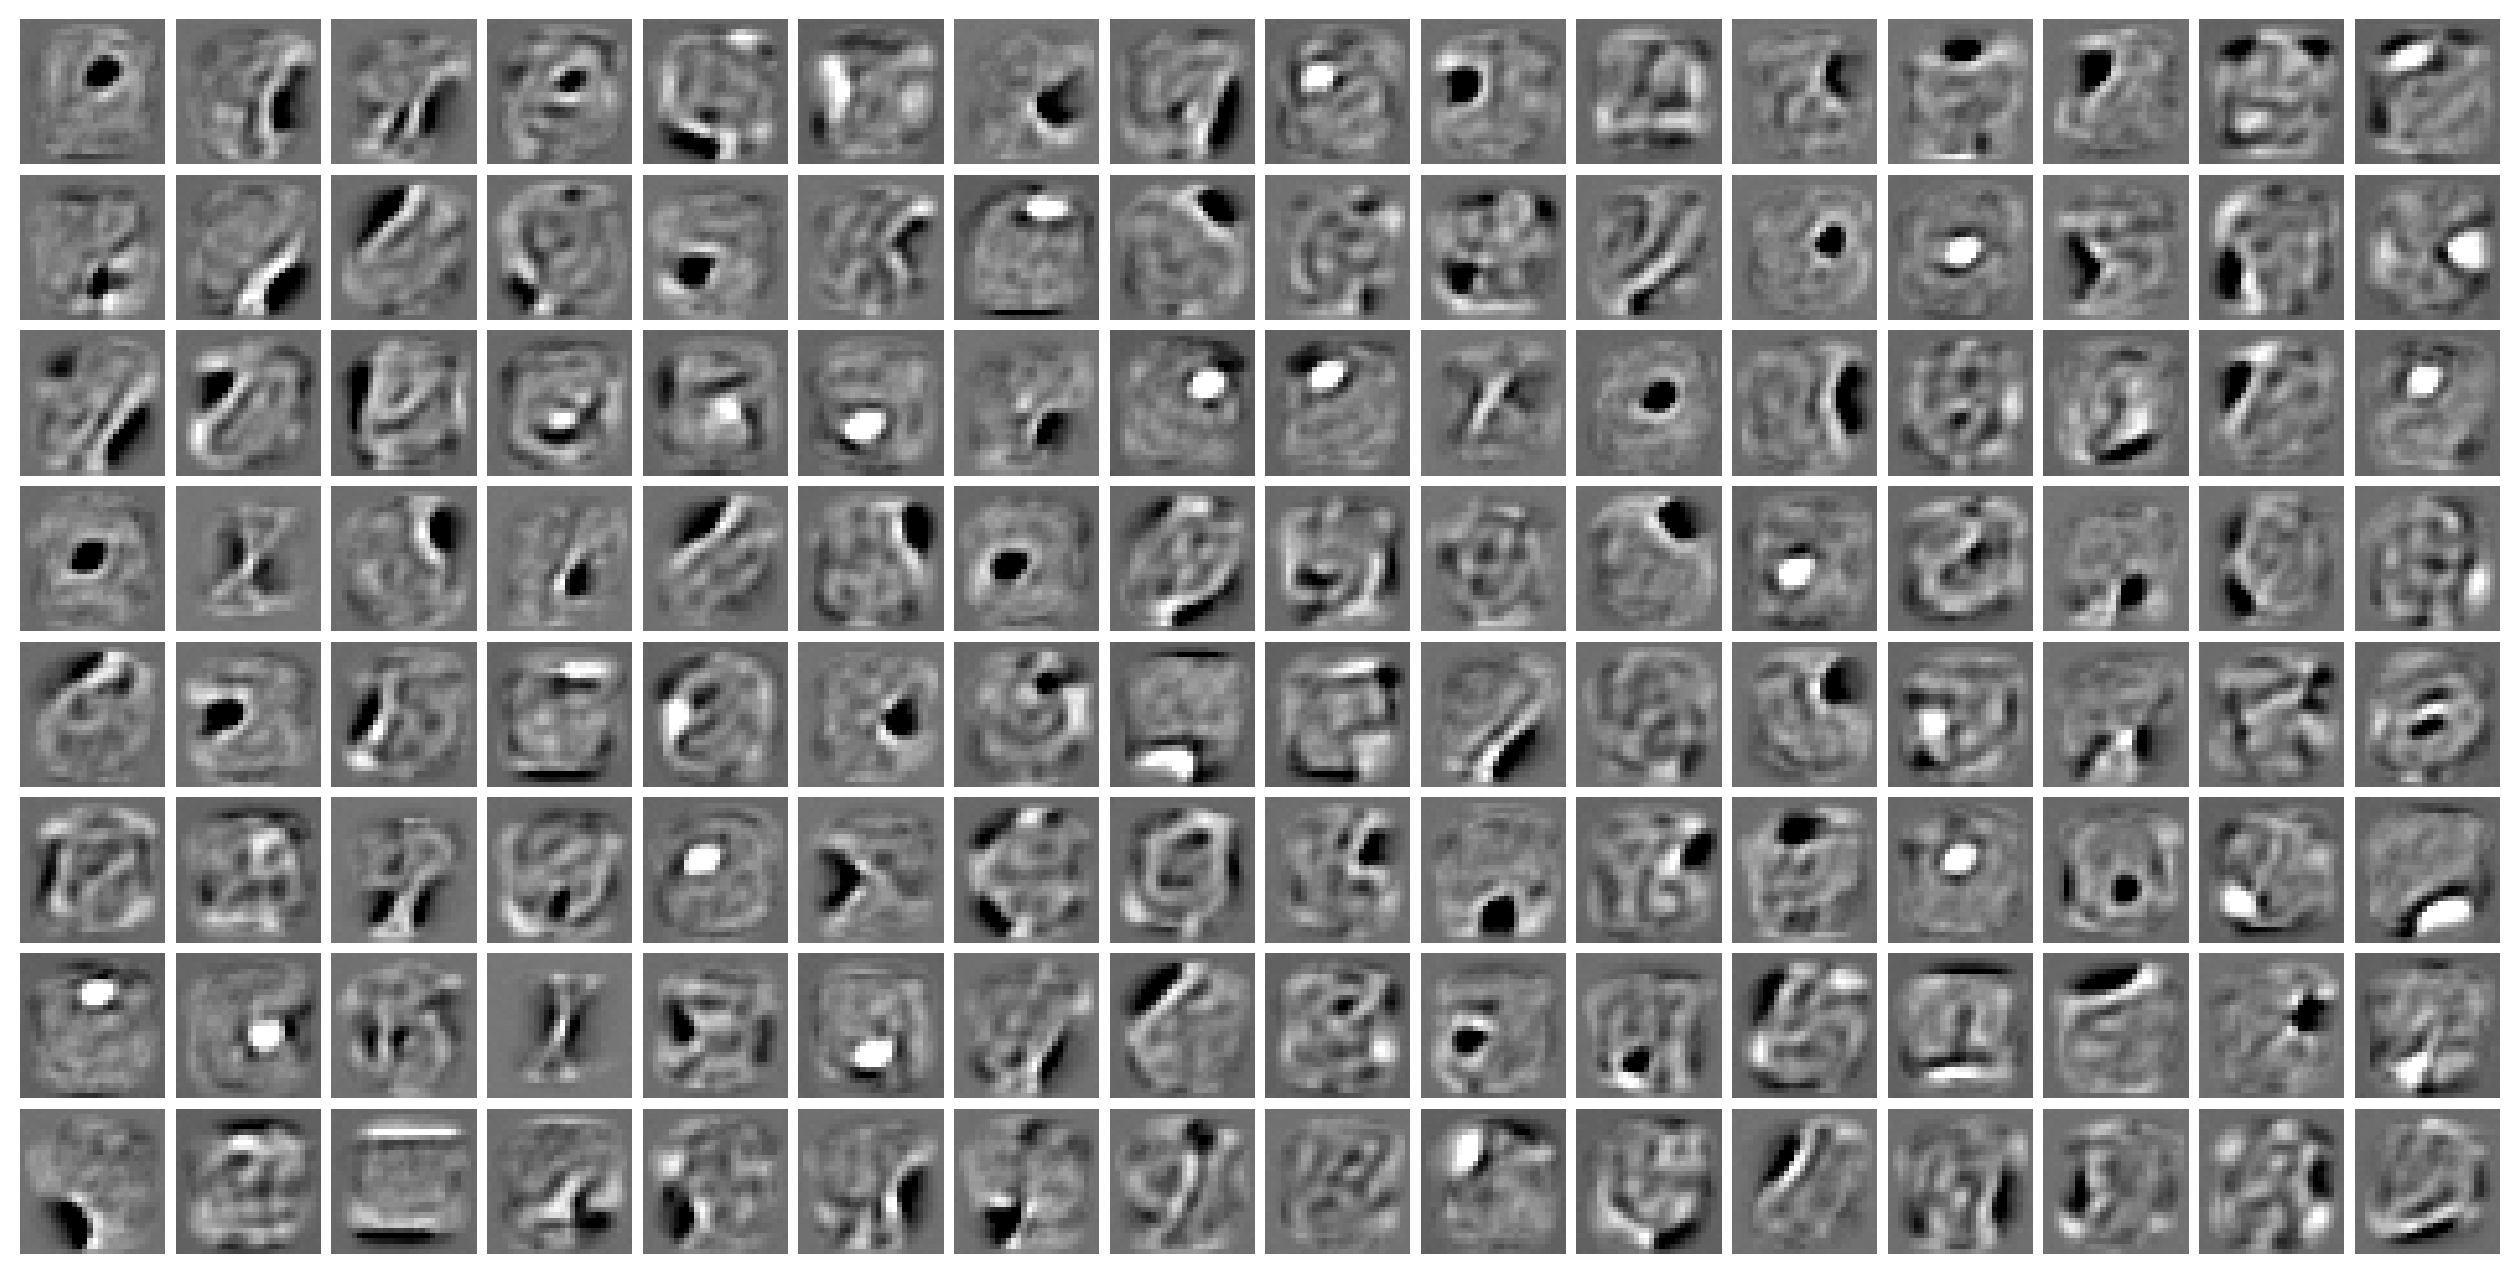

In [43]:
draw_filters(rbm_model)

#### mocniejszy trening "na bogato" ( wygenerowane przez czata )

In [47]:
import time
import numpy as np
import torch
from mnists import MNIST

# ----------------------------
# Device
# ----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ----------------------------
# Helpers
# ----------------------------
def append_ones_np(matrix: np.ndarray) -> np.ndarray:
    return np.concatenate(
        (matrix, np.ones((matrix.shape[0], 1), dtype=np.float32)),
        axis=1
    )

def torch_sigmoid(x: torch.Tensor) -> torch.Tensor:
    return torch.sigmoid(x)

def torch_sample_bernoulli(probs: torch.Tensor) -> torch.Tensor:
    return (probs > torch.rand_like(probs)).float()

# ----------------------------
# Torch RBM
# ----------------------------
class TorchRestrictedBoltzmanMachine:
    def __init__(
        self,
        visible_size: int,
        hidden_size: int,
        learning_rate: float,
        device: torch.device
    ):
        self.visible_size = visible_size
        self.hidden_size = hidden_size
        self.learning_rate = learning_rate
        self.device = device
        self.reset()

    def reset(self) -> None:
        self.W = torch.randn(
            self.visible_size + 1,
            self.hidden_size + 1,
            device=self.device,
            dtype=torch.float32
        ) * 0.01

        self.W[:, -1] = 0.0
        self.W[-1, :] = 0.0

# ----------------------------
# CD-k update
# ----------------------------
def torch_contrastive_divergence_update(
    rbm: TorchRestrictedBoltzmanMachine,
    minibatch: torch.Tensor,
    k: int = 1
) -> None:
    observations_count = minibatch.shape[0]

    # Positive phase
    positive_visible = minibatch
    positive_hidden_probs = torch_sigmoid(positive_visible @ rbm.W)
    positive_hidden_probs[:, -1] = 1.0

    positive_hidden = torch_sample_bernoulli(positive_hidden_probs)
    positive_hidden[:, -1] = 1.0

    # Start Gibbs chain from hidden sample from data
    negative_hidden = positive_hidden.clone()

    for _ in range(k):
        # h -> v
        negative_visible_probs = torch_sigmoid(negative_hidden @ rbm.W.T)
        negative_visible_probs[:, -1] = 1.0

        negative_visible = torch_sample_bernoulli(negative_visible_probs)
        negative_visible[:, -1] = 1.0

        # v -> h
        negative_hidden_probs = torch_sigmoid(negative_visible @ rbm.W)
        negative_hidden_probs[:, -1] = 1.0

        negative_hidden = torch_sample_bernoulli(negative_hidden_probs)
        negative_hidden[:, -1] = 1.0

    positive_gradient = positive_visible.T @ positive_hidden_probs
    negative_gradient = negative_visible.T @ negative_hidden_probs

    rbm.W += rbm.learning_rate * (positive_gradient - negative_gradient) / observations_count

# ----------------------------
# Reconstruction error
# ----------------------------
def torch_reconstruction_error(
    rbm: TorchRestrictedBoltzmanMachine,
    minibatch: torch.Tensor
) -> float:
    hidden_probs = torch_sigmoid(minibatch @ rbm.W)
    hidden_probs[:, -1] = 1.0

    visible_probs = torch_sigmoid(hidden_probs @ rbm.W.T)
    reconstructed = visible_probs[:, :-1]

    error = torch.sum((minibatch[:, :-1] - reconstructed) ** 2) / minibatch.shape[0]
    return float(error.item())

# ----------------------------
# Training config - "mocniejszy trening"
# ----------------------------
DATASET_SIZE: int = 60000
DIGIT_SIZE: int = 28

VISIBLE_LAYER_SIZE: int = DIGIT_SIZE * DIGIT_SIZE
HIDDEN_LAYER_SIZE: int = 256
LEARNING_RATE: float = 0.05

BATCH_SIZE: int = 1024
EPOCHS_COUNT: int = 1000
CD_K: int = 1

# ----------------------------
# Load and prepare MNIST
# ----------------------------
mnist = MNIST()

mnist_train = mnist.train_images().astype(np.float32) / 255.0
np.random.shuffle(mnist_train)

dataset_np = np.reshape(
    mnist_train[:DATASET_SIZE],
    (DATASET_SIZE, DIGIT_SIZE * DIGIT_SIZE)
).astype(np.float32)

dataset_np = append_ones_np(dataset_np)

monitoring_indices = np.random.choice(DATASET_SIZE, 256, replace=False)
monitoring_set_np = dataset_np[monitoring_indices]

dataset_torch = torch.tensor(dataset_np, device=device, dtype=torch.float32)
monitoring_set_torch = torch.tensor(monitoring_set_np, device=device, dtype=torch.float32)

# ----------------------------
# Model
# ----------------------------
rbm_model = TorchRestrictedBoltzmanMachine(
    VISIBLE_LAYER_SIZE,
    HIDDEN_LAYER_SIZE,
    LEARNING_RATE,
    device
)

# ----------------------------
# Epoch training
# ----------------------------
def train_epoch_torch(
    rbm: TorchRestrictedBoltzmanMachine,
    dataset: torch.Tensor
) -> None:
    shuffled_idx = torch.randperm(dataset.shape[0], device=dataset.device)
    shuffled = dataset[shuffled_idx]

    batches_limit = dataset.shape[0] // BATCH_SIZE
    step = max(1, round(batches_limit / 50))

    for batch_idx in range(batches_limit):
        start = batch_idx * BATCH_SIZE
        end = start + BATCH_SIZE
        batch = shuffled[start:end]

        torch_contrastive_divergence_update(rbm, batch, k=CD_K)

        # if batch_idx % step == 0:
        #     print("#", end="")

# ----------------------------
# Train
# ----------------------------
rbm_model.reset()

print("training started")

for epoch in range(EPOCHS_COUNT):
    #rint(f"Epoch {epoch + 1}:\t", end="")

    start_time = time.time()
    train_epoch_torch(rbm_model, dataset_torch)

    if device.type == "cuda":
        torch.cuda.synchronize()

    elapsed = time.time() - start_time
    error = torch_reconstruction_error(rbm_model, monitoring_set_torch)

    #print(f" elapsed: {elapsed:>2.2f}s, reconstruction error: {error:>2.2f}")

print("Training finished!")

Using device: cuda
training started
Training finished!


In [ ]:
#draw_filters(rbm_model)

In [48]:
def draw_filters_cuda(rbm) -> None:
    """
    Visualises the learned RBM weight filters as a grid of 28x28 tiles.
    Works with both NumPy-based RBM and Torch-based RBM.
    """
    if isinstance(rbm.W, torch.Tensor):
        W = rbm.W.detach().cpu().numpy()
    else:
        W = rbm.W

    filters: np.ndarray = np.reshape(
        np.transpose(W)[:-1, :-1],
        (8, -1, 28, 28)
    )
    filters = np.clip(filters, -1, 1)
    preview_tiles(filters)

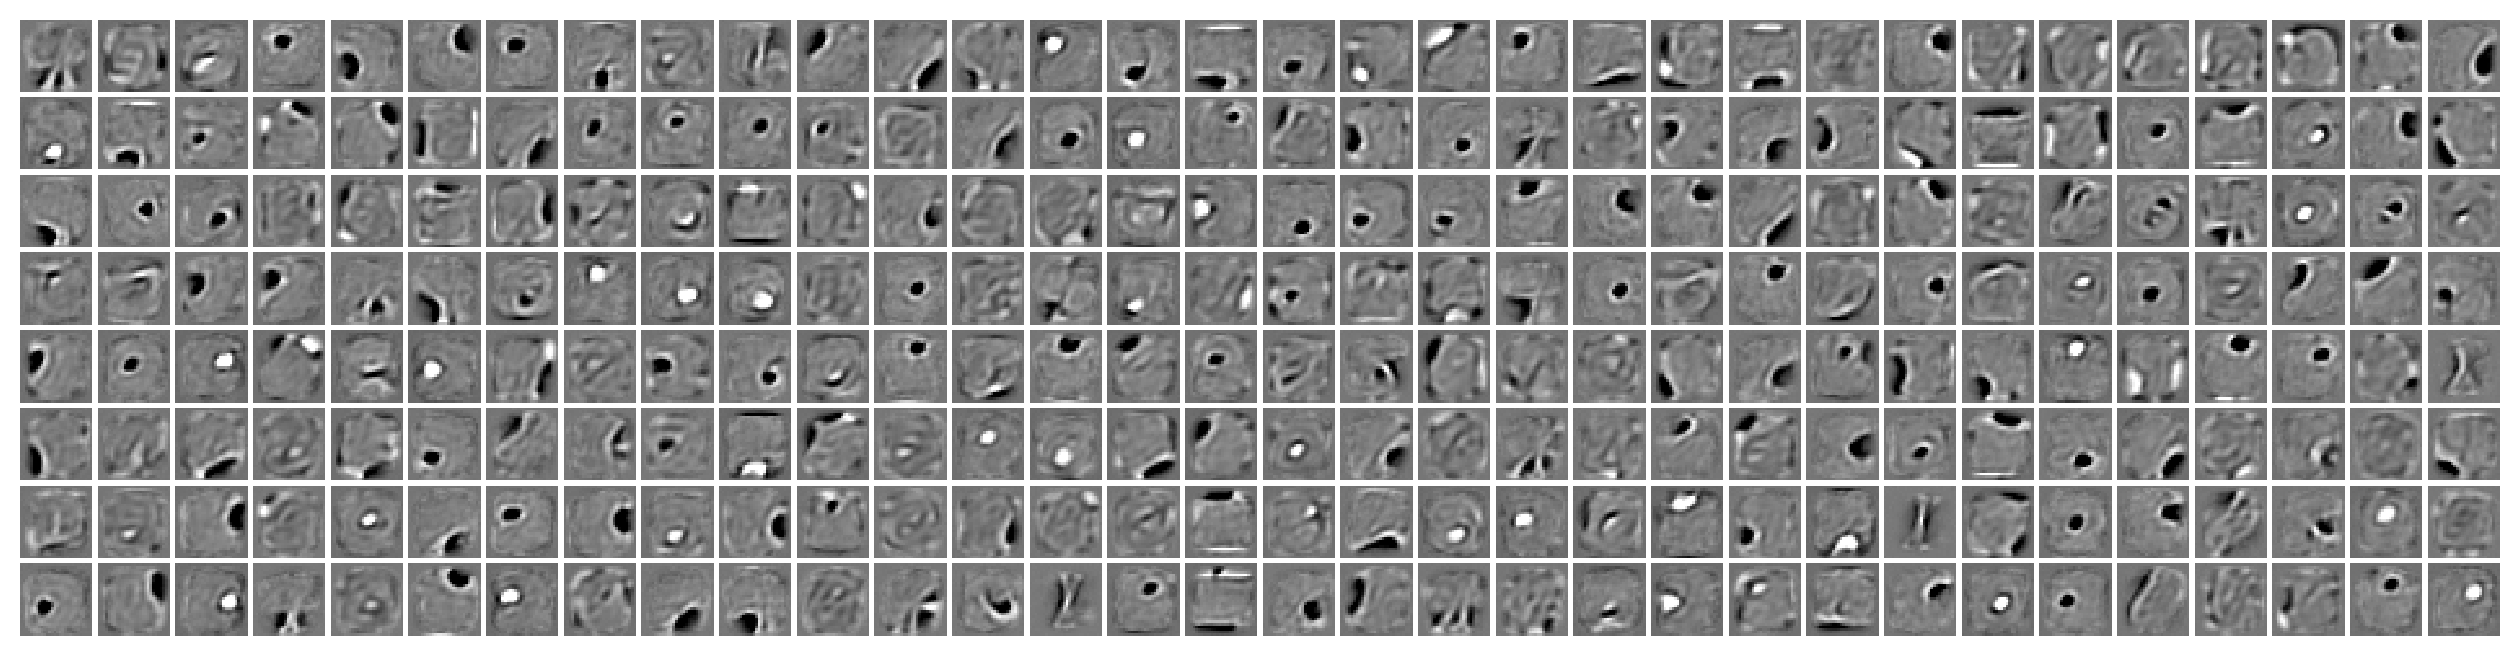

In [49]:
draw_filters_cuda(rbm_model)